In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/csdeeraj/free-time-activity-dataset/Free_Time_Activity_Dataset.csv


In [26]:
# Import the required libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [27]:
# Read the dataset
df=pd.read_csv("/kaggle/input/datasets/csdeeraj/free-time-activity-dataset/Free_Time_Activity_Dataset.csv")

In [28]:
# Display the first five rows
df.head()
# Display information about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Weather      100 non-null    object
 1   Temperature  100 non-null    object
 2   Humidity     100 non-null    object
 3   Wind         100 non-null    object
 4   Weekend      100 non-null    object
 5   HasCompany   100 non-null    object
 6   Mood         100 non-null    object
 7   Activity     100 non-null    object
dtypes: object(8)
memory usage: 6.4+ KB


In [29]:
encoders={}
for column in df.columns:
    encoders[column]=LabelEncoder()
    df[column]=encoders[column].fit_transform(df[column])

In [30]:
# Select the input features
X=df.drop("Activity",axis=1)
# Select the output
y=df["Activity"]

In [31]:
# Split the dataset into training and testing sets
Xtrain,Xtest,ytrain,ytest=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
# Create the Decision Tree model
model=DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)
# Train the model
model.fit(Xtrain,ytrain)
print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [33]:
# Predict the test data
ypred=model.predict(Xtest)

print("Predicted Values")
print(ypred)
# Display the model accuracy
print("Accuracy :",accuracy_score(ytest,ypred))

Predicted Values
[0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1]
Accuracy : 0.65


In [34]:
# Display the classification report
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.64      0.82      0.72        11
           1       0.67      0.44      0.53         9

    accuracy                           0.65        20
   macro avg       0.65      0.63      0.63        20
weighted avg       0.65      0.65      0.64        20



In [35]:
# Display the confusion matrix
cm=confusion_matrix(ytest,ypred)

print(cm)

[[9 2]
 [5 4]]


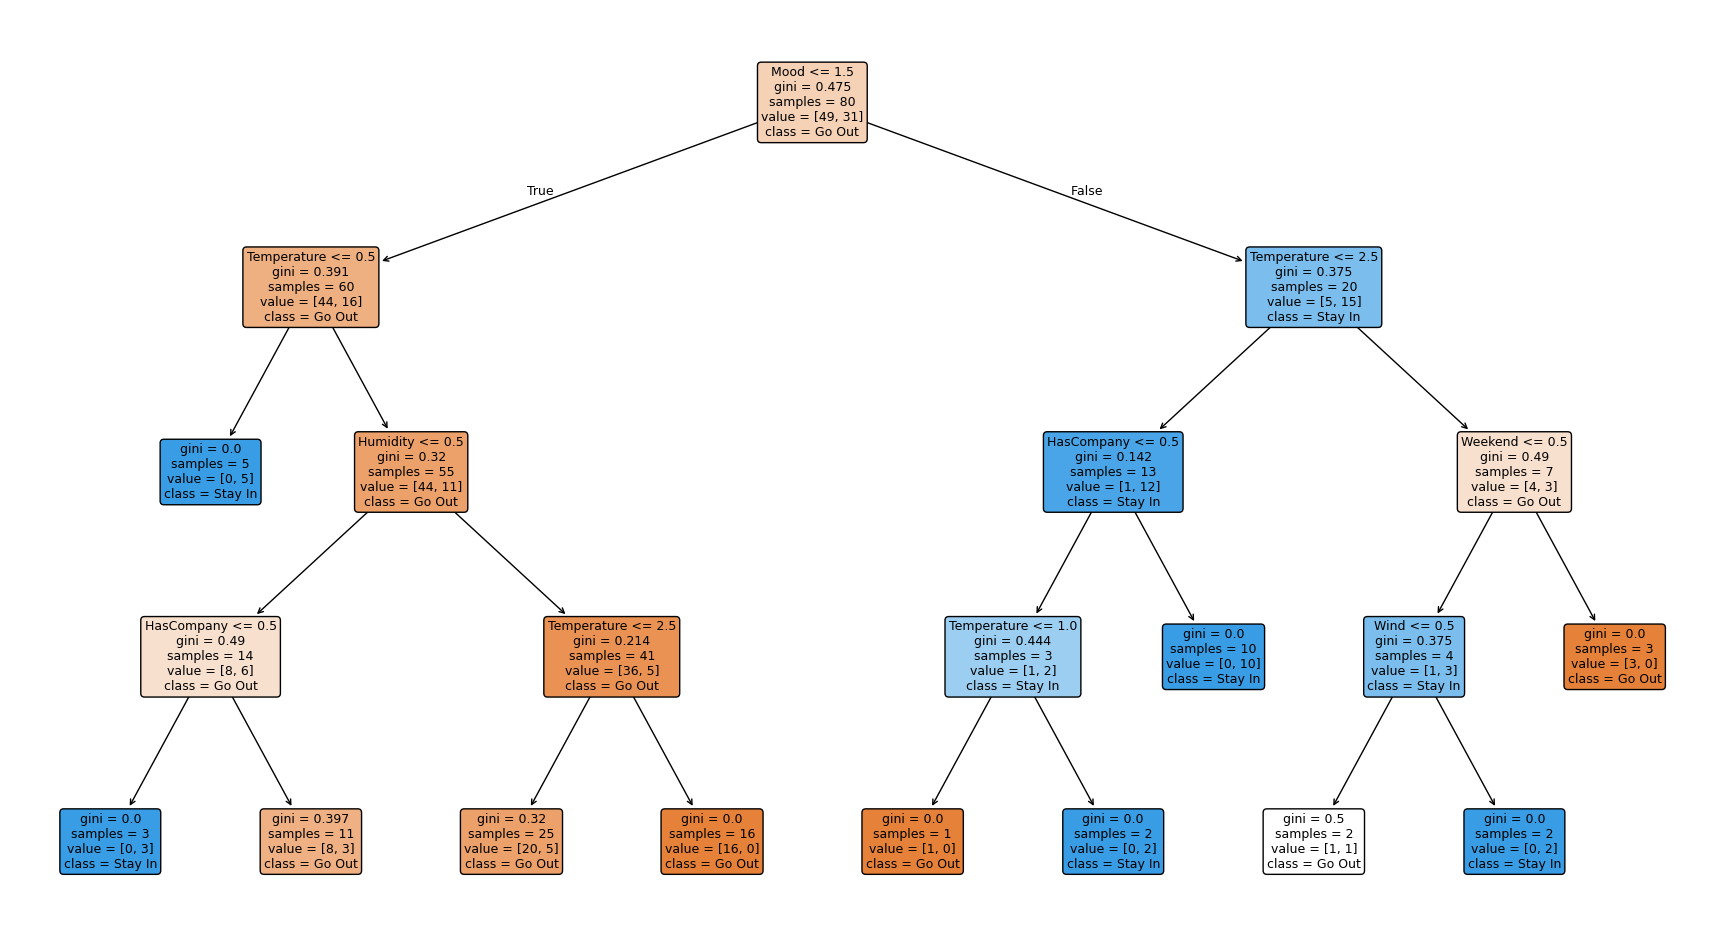

In [36]:
# Plot the decision tree
plt.figure(figsize=(22,12))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Go Out","Stay In"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.show()